<a href="https://colab.research.google.com/github/w1t1ta/Project_01/blob/main/test_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image Size: (1536, 2048)
Original Image Size: (1536, 2048)


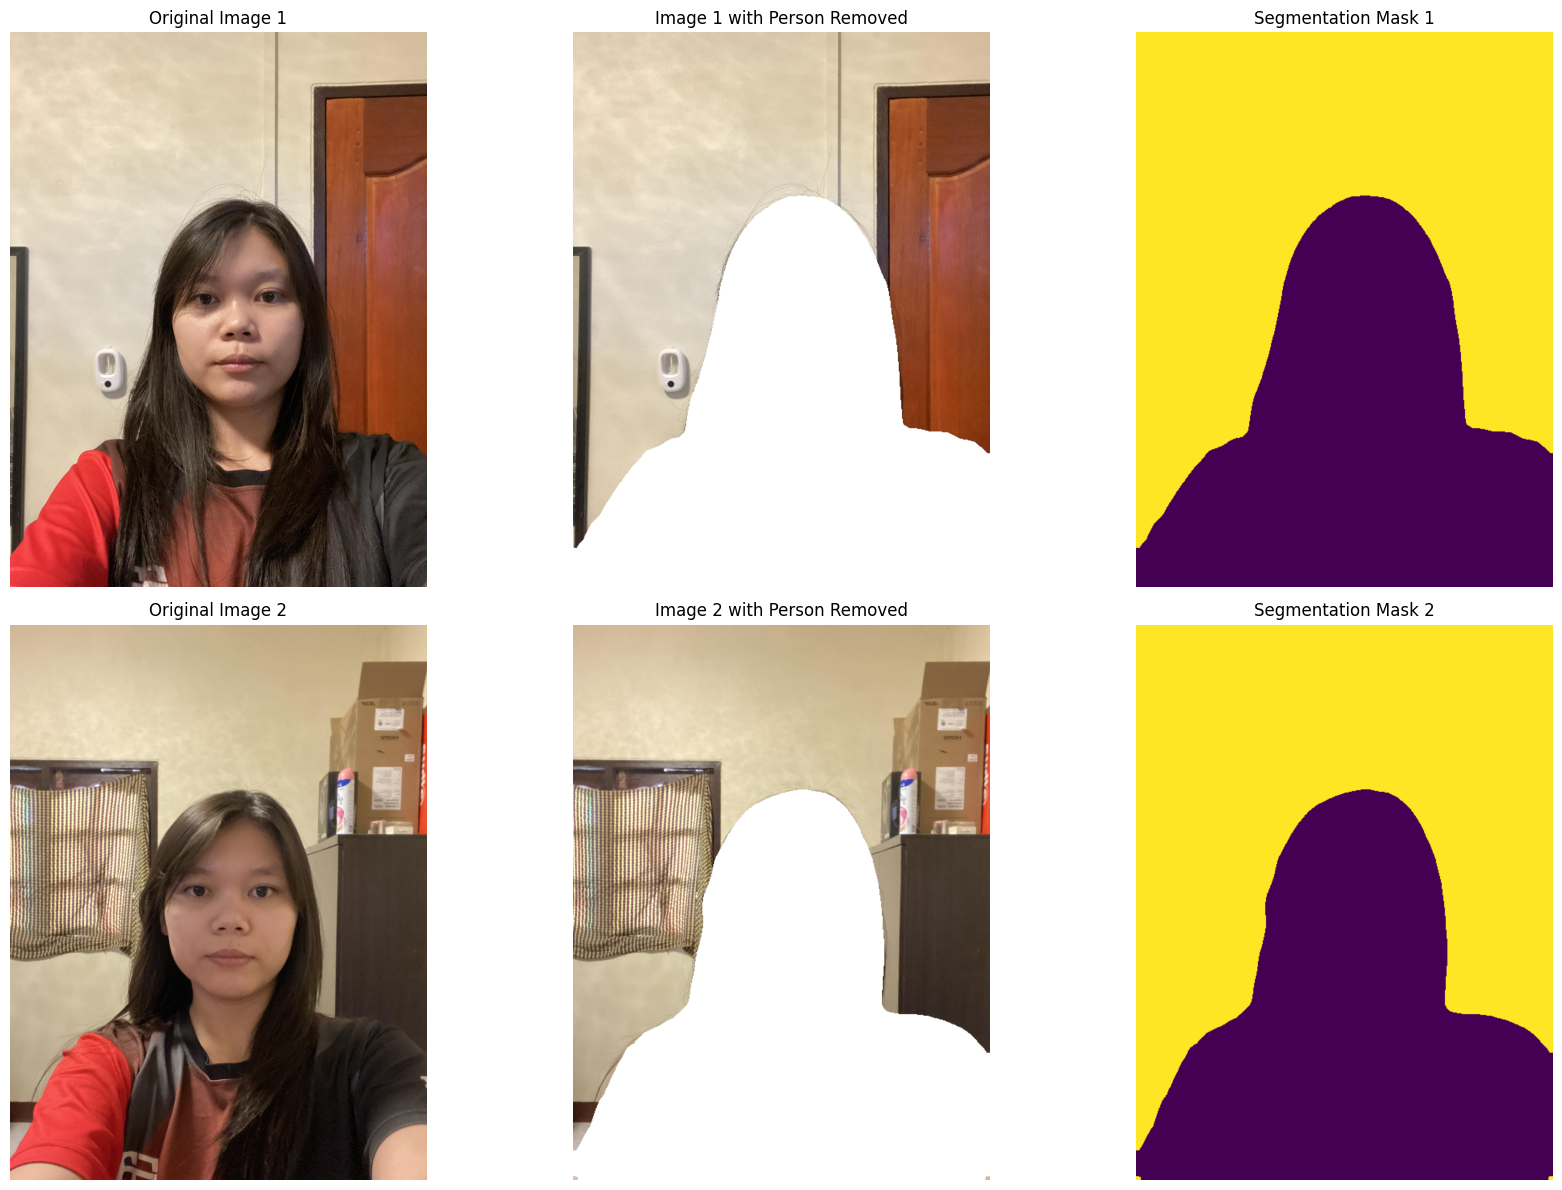

Images have been saved to the 'output' folder.


In [37]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from torchvision import models
import cv2

# โหลดโมเดล DeepLabV3+ ที่พรีเทรนแล้ว
model = models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()  # ตั้งโมเดลเป็นโหมดทำนาย

# โหลดภาพที่ต้องการทดสอบ
image_path1 = '/content/486162522_617138504815285_7348884604077297056_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 1
image_path2 = '/content/487094535_668836015532232_8047246504063472500_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 2

# ฟังก์ชันในการประมวลผลภาพ
def process_image(image_path):
    image = Image.open(image_path)

    # ตรวจสอบขนาดของภาพก่อนทำการแปลง
    print(f"Original Image Size: {image.size}")

    # แปลงภาพจาก PIL เป็น Tensor สำหรับโมเดล
    transform = T.Compose([T.Resize(520), T.ToTensor()])
    input_image = transform(image).unsqueeze(0)  # แปลงเป็น tensor และเพิ่ม batch dimension

    # ทำนายผลลัพธ์
    with torch.no_grad():
        output = model(input_image)['out'][0]  # นำผลลัพธ์จากโมเดล
    output_predictions = output.argmax(0)  # ใช้ argmax เพื่อหา class ที่สูงที่สุด

    # สร้าง mask เพื่อหาพื้นหลัง
    person_mask = output_predictions != 15  # 15 คือตัวเลขของบุคคลใน DeepLabV3+

    # แปลง person_mask เป็น NumPy array
    person_mask_np = person_mask.cpu().numpy()

    # Resize the mask to the original image size
    person_mask_np = cv2.resize(person_mask_np.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)

    # แปลงภาพเป็น numpy array
    image_array = np.array(image)

    # สร้างภาพใหม่ที่ลบบุคคลออกจากภาพ (โดยการใช้ mask)
    image_with_no_person = np.dstack([image_array, person_mask_np * 255])

    # แปลงกลับเป็นภาพ PIL
    result_image = Image.fromarray(image_with_no_person)

    return image, result_image, person_mask_np

# ประมวลผลภาพทั้งสอง
image1, result_image1, mask1 = process_image(image_path1)
image2, result_image2, mask2 = process_image(image_path2)

# แสดงภาพทั้งสอง
fig, axarr = plt.subplots(2, 3, figsize=(18, 12))

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพแรก
axarr[0, 0].imshow(image1)
axarr[0, 0].set_title('Original Image 1')
axarr[0, 0].axis('off')

axarr[0, 1].imshow(result_image1)
axarr[0, 1].set_title('Image 1 with Person Removed')
axarr[0, 1].axis('off')

axarr[0, 2].imshow(Image.fromarray(mask1.astype(np.uint8) * 255))
axarr[0, 2].set_title('Segmentation Mask 1')
axarr[0, 2].axis('off')

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพที่สอง
axarr[1, 0].imshow(image2)
axarr[1, 0].set_title('Original Image 2')
axarr[1, 0].axis('off')

axarr[1, 1].imshow(result_image2)
axarr[1, 1].set_title('Image 2 with Person Removed')
axarr[1, 1].axis('off')

axarr[1, 2].imshow(Image.fromarray(mask2.astype(np.uint8) * 255))
axarr[1, 2].set_title('Segmentation Mask 2')
axarr[1, 2].axis('off')

plt.tight_layout()
plt.show()

# บันทึกผลลัพธ์ลงในโฟลเดอร์ 'output'
output_folder = 'output'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# สกัดชื่อไฟล์จาก path
base_name1 = os.path.basename(image_path1).split('.')[0]
base_name2 = os.path.basename(image_path2).split('.')[0]

# บันทึกภาพต้นฉบับ
image1.save(os.path.join(output_folder, f'{base_name1}_original_image1.jpg'))
image2.save(os.path.join(output_folder, f'{base_name2}_original_image2.jpg'))

# บันทึกภาพผลลัพธ์
result_image1.save(os.path.join(output_folder, f'{base_name1}_image1_with_person_removed.png'))
result_image2.save(os.path.join(output_folder, f'{base_name2}_image2_with_person_removed.png'))

# บันทึก segmentation mask
Image.fromarray(mask1.astype(np.uint8) * 255).save(os.path.join(output_folder, f'{base_name1}_segmentation_mask1.png'))
Image.fromarray(mask2.astype(np.uint8) * 255).save(os.path.join(output_folder, f'{base_name2}_segmentation_mask2.png'))

print("Images have been saved to the 'output' folder.")


Original Image Size: (828, 1104)
Original Image Size: (828, 1104)


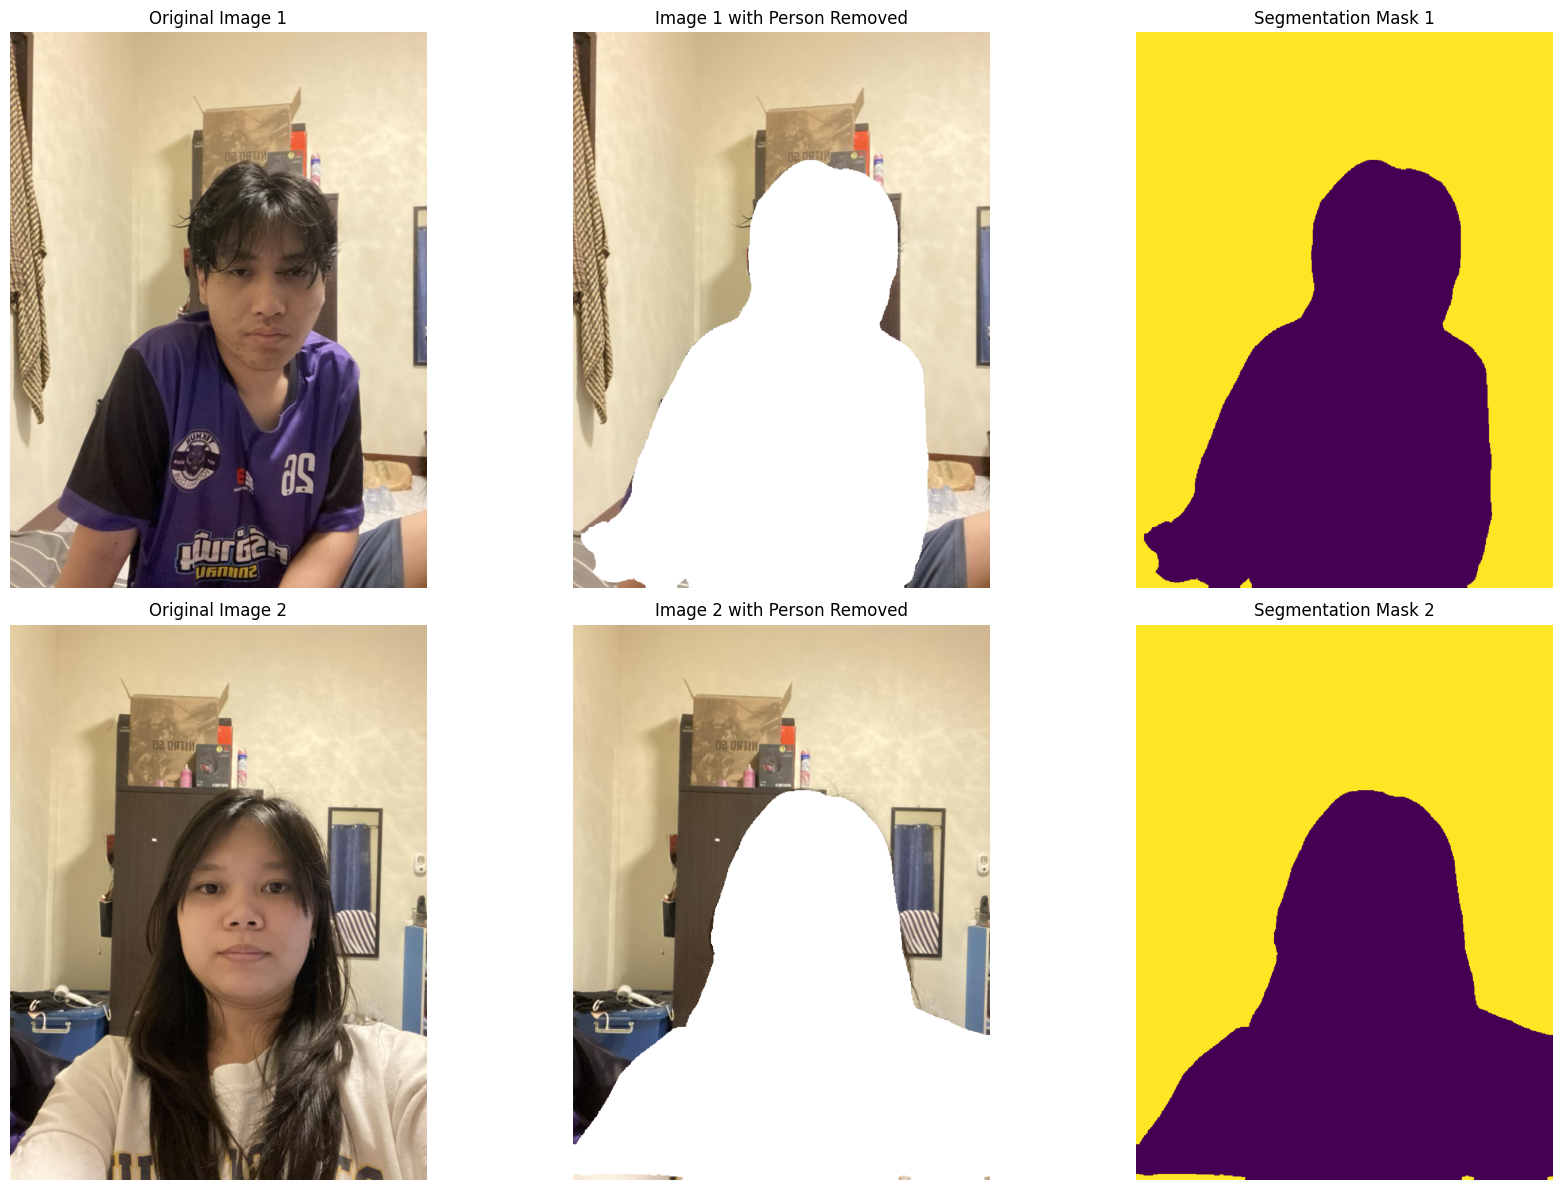

Images have been saved to the 'output' folder.


In [38]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from torchvision import models
import cv2

# โหลดโมเดล DeepLabV3+ ที่พรีเทรนแล้ว
model = models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()  # ตั้งโมเดลเป็นโหมดทำนาย

# โหลดภาพที่ต้องการทดสอบ
image_path1 = '/content/484306100_1607547476614172_7718928177540118125_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 1
image_path2 = '/content/484780875_954835580188785_170552539904722165_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 2

# ฟังก์ชันในการประมวลผลภาพ
def process_image(image_path):
    image = Image.open(image_path)

    # ตรวจสอบขนาดของภาพก่อนทำการแปลง
    print(f"Original Image Size: {image.size}")

    # แปลงภาพจาก PIL เป็น Tensor สำหรับโมเดล
    transform = T.Compose([T.Resize(520), T.ToTensor()])
    input_image = transform(image).unsqueeze(0)  # แปลงเป็น tensor และเพิ่ม batch dimension

    # ทำนายผลลัพธ์
    with torch.no_grad():
        output = model(input_image)['out'][0]  # นำผลลัพธ์จากโมเดล
    output_predictions = output.argmax(0)  # ใช้ argmax เพื่อหา class ที่สูงที่สุด

    # สร้าง mask เพื่อหาพื้นหลัง
    person_mask = output_predictions != 15  # 15 คือตัวเลขของบุคคลใน DeepLabV3+

    # แปลง person_mask เป็น NumPy array
    person_mask_np = person_mask.cpu().numpy()

    # Resize the mask to the original image size
    person_mask_np = cv2.resize(person_mask_np.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)

    # แปลงภาพเป็น numpy array
    image_array = np.array(image)

    # สร้างภาพใหม่ที่ลบบุคคลออกจากภาพ (โดยการใช้ mask)
    image_with_no_person = np.dstack([image_array, person_mask_np * 255])

    # แปลงกลับเป็นภาพ PIL
    result_image = Image.fromarray(image_with_no_person)

    return image, result_image, person_mask_np

# ประมวลผลภาพทั้งสอง
image1, result_image1, mask1 = process_image(image_path1)
image2, result_image2, mask2 = process_image(image_path2)

# แสดงภาพทั้งสอง
fig, axarr = plt.subplots(2, 3, figsize=(18, 12))

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพแรก
axarr[0, 0].imshow(image1)
axarr[0, 0].set_title('Original Image 1')
axarr[0, 0].axis('off')

axarr[0, 1].imshow(result_image1)
axarr[0, 1].set_title('Image 1 with Person Removed')
axarr[0, 1].axis('off')

axarr[0, 2].imshow(Image.fromarray(mask1.astype(np.uint8) * 255))
axarr[0, 2].set_title('Segmentation Mask 1')
axarr[0, 2].axis('off')

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพที่สอง
axarr[1, 0].imshow(image2)
axarr[1, 0].set_title('Original Image 2')
axarr[1, 0].axis('off')

axarr[1, 1].imshow(result_image2)
axarr[1, 1].set_title('Image 2 with Person Removed')
axarr[1, 1].axis('off')

axarr[1, 2].imshow(Image.fromarray(mask2.astype(np.uint8) * 255))
axarr[1, 2].set_title('Segmentation Mask 2')
axarr[1, 2].axis('off')

plt.tight_layout()
plt.show()

# บันทึกผลลัพธ์ลงในโฟลเดอร์ 'output'
output_folder = 'output'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# สกัดชื่อไฟล์จาก path
base_name1 = os.path.basename(image_path1).split('.')[0]
base_name2 = os.path.basename(image_path2).split('.')[0]

# บันทึกภาพต้นฉบับ
image1.save(os.path.join(output_folder, f'{base_name1}_original_image1.jpg'))
image2.save(os.path.join(output_folder, f'{base_name2}_original_image2.jpg'))

# บันทึกภาพผลลัพธ์
result_image1.save(os.path.join(output_folder, f'{base_name1}_image1_with_person_removed.png'))
result_image2.save(os.path.join(output_folder, f'{base_name2}_image2_with_person_removed.png'))

# บันทึก segmentation mask
Image.fromarray(mask1.astype(np.uint8) * 255).save(os.path.join(output_folder, f'{base_name1}_segmentation_mask1.png'))
Image.fromarray(mask2.astype(np.uint8) * 255).save(os.path.join(output_folder, f'{base_name2}_segmentation_mask2.png'))

print("Images have been saved to the 'output' folder.")


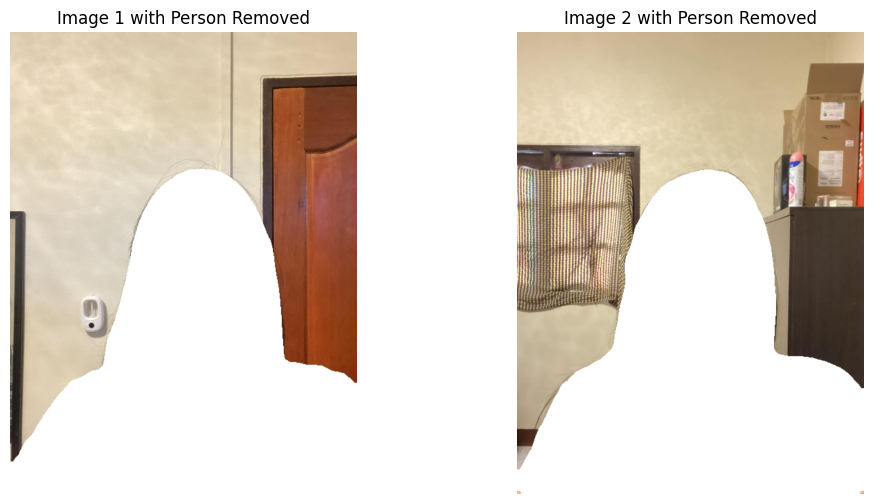

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

# โหลดภาพจาก path ที่บันทึกไว้
image_path1 = "/content/output/image1_with_person_removed.png"
image_path2 = "/content/output/image2_with_person_removed.png"

image1 = Image.open(image_path1)
image2 = Image.open(image_path2)

# แสดงภาพ
fig, axarr = plt.subplots(1, 2, figsize=(12, 6))

# แสดงภาพแรก
axarr[0].imshow(image1)
axarr[0].set_title("Image 1 with Person Removed")
axarr[0].axis("off")

# แสดงภาพที่สอง
axarr[1].imshow(image2)
axarr[1].set_title("Image 2 with Person Removed")
axarr[1].axis("off")

plt.show()

In [1]:
!pip install numpy==1.26.4
!pip install scipy==1.11.4
!pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cu118
!pip install git+https://github.com/openai/CLIP.git
!pip install transformers==4.37.2 huggingface_hub


Looking in indexes: https://download.pytorch.org/whl/cu118
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-qvhmerqb
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-qvhmerqb
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 58.5 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.1
    Uninstalling tokenizers-0.21.1:
      Successfully uninstalled tokenizers-0.21.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.50.3
    Uninstalling transformers-4.50.3:
      Successfully uninstalled transformers-4.50.3
ERROR: pip's dependency

In [2]:
import torch
from PIL import Image
from torchvision import transforms
import clip
from transformers import AutoProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
#CLIP
def get_clip_similarity(img1_path, img2_path):
    model, preprocess = clip.load("ViT-B/32", device=device)
    img1 = preprocess(Image.open(img1_path)).unsqueeze(0).to(device)
    img2 = preprocess(Image.open(img2_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        f1 = model.encode_image(img1)
        f2 = model.encode_image(img2)
    return torch.cosine_similarity(f1, f2).item()

#ReVA
def get_reva_similarity(img1_path, img2_path):
    processor = AutoProcessor.from_pretrained("NAVER/reva-clip-vit-base-patch32")
    model = AutoModel.from_pretrained("NAVER/reva-clip-vit-base-patch32").to(device)
    images = [Image.open(img1_path).convert("RGB"), Image.open(img2_path).convert("RGB")]
    inputs = processor(images=images, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    return torch.cosine_similarity(image_features[0].unsqueeze(0), image_features[1].unsqueeze(0)).item()

In [4]:
img_path1 = "/content/output/image1_with_person_removed.png"
img_path2 = "/content/output/image2_with_person_removed.png"

print("CLIP similarity:", get_clip_similarity(img_path1, img_path2))
print("ReVA similarity:", get_reva_similarity(img_path1, img_path2))

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 124MiB/s]


CLIP similarity: 0.9332637786865234


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


OSError: NAVER/reva-clip-vit-base-patch32 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

CLIP similarity score: 0.9178


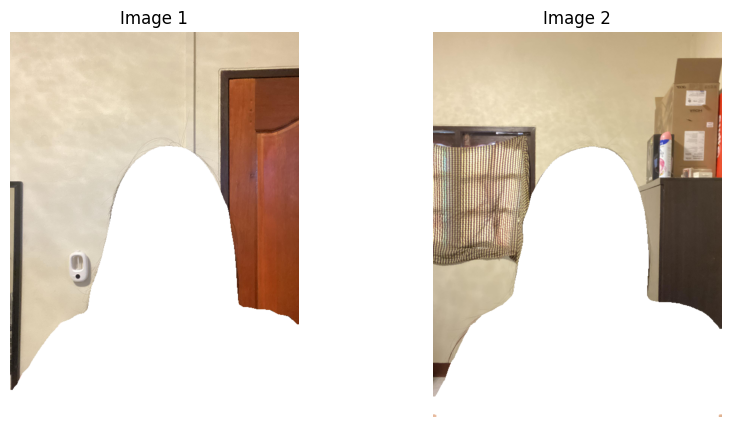

In [11]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

# โหลดโมเดล CLIP ที่เป็น public และใช้งานได้
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

# โหลดภาพ 2 ภาพที่ต้องการเทียบ
image1 = Image.open("/content/output/image1_with_person_removed.png")
image2 = Image.open("/content/output/image2_with_person_removed.png")

# ใช้ processor แปลงภาพให้เหมาะกับโมเดล
inputs = processor(images=[image1, image2], return_tensors="pt").to(device)

# ดึง feature embeddings
with torch.no_grad():
    image_features = model.get_image_features(**inputs)

# ปรับขนาดให้ normalize เป็น unit vector
image_features = image_features / image_features.norm(dim=-1, keepdim=True)

# คำนวณ cosine similarity ระหว่างภาพ 2 ภาพ
similarity = (image_features[0] @ image_features[1].T).item()

# แสดงภาพและ similarity
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Image 2")
plt.axis("off")

print(f"CLIP similarity score: {similarity:.4f}")
plt.show()


CLIP similarity score: 0.9178


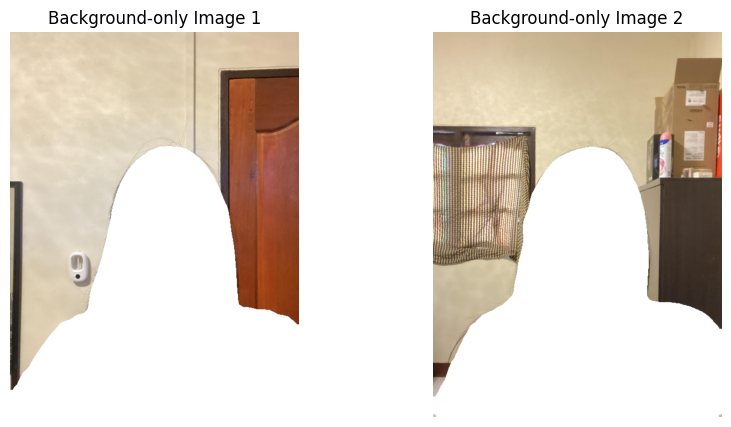

In [13]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

# โหลดโมเดล CLIP ที่เป็น public และใช้งานได้
model_name = "openai/clip-vit-base-patch32"
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

# โหลดภาพ 2 ภาพที่มีเฉพาะพื้นหลังที่ตัดจาก DeepLabv3+
image1 = Image.open("/content/output/image1_with_person_removed.png")
image2 = Image.open("/content/output/image2_with_person_removed.png")

# ใช้ processor แปลงภาพให้เหมาะกับโมเดล
inputs = processor(images=[image1, image2], return_tensors="pt").to(device)

# ดึง feature embeddings
with torch.no_grad():
    image_features = model.get_image_features(**inputs)

# ปรับขนาดให้ normalize เป็น unit vector
image_features = image_features / image_features.norm(dim=-1, keepdim=True)

# คำนวณ cosine similarity ระหว่างภาพ 2 ภาพ
similarity = (image_features[0] @ image_features[1].T).item()

# แสดงภาพและ similarity
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Background-only Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Background-only Image 2")
plt.axis("off")

print(f"CLIP similarity score: {similarity:.4f}")
plt.show()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments oth

CLIP Similarity Score: 0.9178
VGG16 Similarity Score: 0.4745
ResNet Similarity Score: 0.8329
Siamese Network Similarity Score: 0.9964


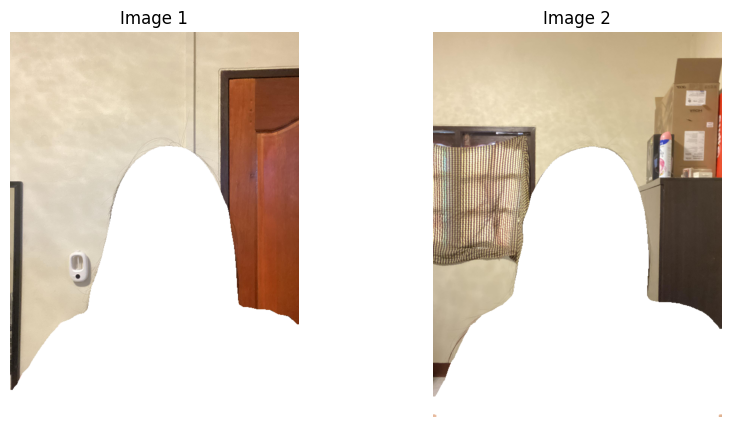

In [20]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
from torchvision import models, transforms
from torch import nn

# กำหนด device
device = "cuda" if torch.cuda.is_available() else "cpu"

# โหลดโมเดล CLIP (openai/clip-vit-base-patch32)
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# โหลดโมเดล VGG16 หรือ VGG19
vgg_model = models.vgg16(pretrained=True).to(device)
vgg_model.eval()

# โหลดโมเดล ResNet
resnet_model = models.resnet50(pretrained=True).to(device)
resnet_model.eval()

# โหลดภาพที่ตัดคนออก
image1 = Image.open("/content/output/image1_with_person_removed.png")
image2 = Image.open("/content/output/image2_with_person_removed.png")

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ CLIP
def clip_similarity(image1, image2):
    inputs = clip_processor(images=[image1, image2], return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
    # ปรับขนาดและ normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features[0] @ image_features[1].T).item()
    return similarity

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ VGG16
def vgg_similarity(image1, image2):
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    # Convert image to RGB before converting to tensor
    image1 = transform(image1.convert('RGB')).unsqueeze(0).to(device)
    image2 = transform(image2.convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        features1 = vgg_model.features(image1)
        features2 = vgg_model.features(image2)

    # ใช้ Cosine similarity
    similarity = nn.functional.cosine_similarity(features1.view(-1), features2.view(-1), dim=0)
    return similarity.item()

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ ResNet
def resnet_similarity(image1, image2):
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    # Convert the image to RGB to remove the alpha channel
    image1 = transform(image1.convert('RGB')).unsqueeze(0).to(device)
    image2 = transform(image2.convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        features1 = resnet_model(image1)
        features2 = resnet_model(image2)

    # ใช้ Cosine similarity
    similarity = nn.functional.cosine_similarity(features1.view(-1), features2.view(-1), dim=0)
    return similarity.item()

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ Siamese Network
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.model = models.resnet50(pretrained=True)  # ใช้ ResNet50
        self.model.fc = nn.Identity()  # ไม่ใช้ fully connected layer

    def forward(self, x):
        return self.model(x)

def siamese_similarity(image1, image2):
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    # Convert the image to RGB to remove the alpha channel
    image1 = transform(image1.convert('RGB')).unsqueeze(0).to(device) # Convert to RGB
    image2 = transform(image2.convert('RGB')).unsqueeze(0).to(device) # Convert to RGB

    siamese_model = SiameseNetwork().to(device)

    with torch.no_grad():
        feature1 = siamese_model(image1)
        feature2 = siamese_model(image2)

    similarity = nn.functional.cosine_similarity(feature1.view(-1), feature2.view(-1), dim=0)
    return similarity.item()

# เปรียบเทียบภาพ
clip_score = clip_similarity(image1, image2)
vgg_score = vgg_similarity(image1, image2)
resnet_score = resnet_similarity(image1, image2)
siamese_score = siamese_similarity(image1, image2)

# แสดงผล
print(f"CLIP Similarity Score: {clip_score:.4f}")
print(f"VGG16 Similarity Score: {vgg_score:.4f}")
print(f"ResNet Similarity Score: {resnet_score:.4f}")
print(f"Siamese Network Similarity Score: {siamese_score:.4f}")

# แสดงภาพ
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Image 2")
plt.axis("off")

plt.show()

CLIP Similarity Score: 0.8176
VGG16 Similarity Score: 0.3389
ResNet Similarity Score: 0.7258
Siamese Network Similarity Score: 0.9961


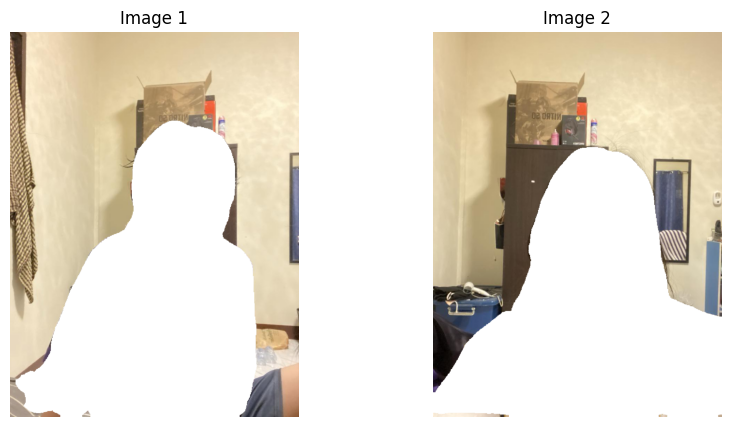

In [22]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
from torchvision import models, transforms
from torch import nn

# กำหนด device
device = "cuda" if torch.cuda.is_available() else "cpu"

# โหลดโมเดล CLIP (openai/clip-vit-base-patch32)
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# โหลดโมเดล VGG16 หรือ VGG19
vgg_model = models.vgg16(pretrained=True).to(device)
vgg_model.eval()

# โหลดโมเดล ResNet
resnet_model = models.resnet50(pretrained=True).to(device)
resnet_model.eval()

# โหลดภาพที่ตัดคนออก
image1 = Image.open("/content/output/image1_with_person_removed.png")
image2 = Image.open("/content/output/image2_with_person_removed.png")

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ CLIP
def clip_similarity(image1, image2):
    inputs = clip_processor(images=[image1, image2], return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
    # ปรับขนาดและ normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features[0] @ image_features[1].T).item()
    return similarity

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ VGG16
def vgg_similarity(image1, image2):
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    # Convert image to RGB before converting to tensor
    image1 = transform(image1.convert('RGB')).unsqueeze(0).to(device)
    image2 = transform(image2.convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        features1 = vgg_model.features(image1)
        features2 = vgg_model.features(image2)

    # ใช้ Cosine similarity
    similarity = nn.functional.cosine_similarity(features1.view(-1), features2.view(-1), dim=0)
    return similarity.item()

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ ResNet
def resnet_similarity(image1, image2):
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    # Convert the image to RGB to remove the alpha channel
    image1 = transform(image1.convert('RGB')).unsqueeze(0).to(device)
    image2 = transform(image2.convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        features1 = resnet_model(image1)
        features2 = resnet_model(image2)

    # ใช้ Cosine similarity
    similarity = nn.functional.cosine_similarity(features1.view(-1), features2.view(-1), dim=0)
    return similarity.item()

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ Siamese Network
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.model = models.resnet50(pretrained=True)  # ใช้ ResNet50
        self.model.fc = nn.Identity()  # ไม่ใช้ fully connected layer

    def forward(self, x):
        return self.model(x)

def siamese_similarity(image1, image2):
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    # Convert the image to RGB to remove the alpha channel
    image1 = transform(image1.convert('RGB')).unsqueeze(0).to(device) # Convert to RGB
    image2 = transform(image2.convert('RGB')).unsqueeze(0).to(device) # Convert to RGB

    siamese_model = SiameseNetwork().to(device)

    with torch.no_grad():
        feature1 = siamese_model(image1)
        feature2 = siamese_model(image2)

    similarity = nn.functional.cosine_similarity(feature1.view(-1), feature2.view(-1), dim=0)
    return similarity.item()

# เปรียบเทียบภาพ
clip_score = clip_similarity(image1, image2)
vgg_score = vgg_similarity(image1, image2)
resnet_score = resnet_similarity(image1, image2)
siamese_score = siamese_similarity(image1, image2)

# แสดงผล
print(f"CLIP Similarity Score: {clip_score:.4f}")
print(f"VGG16 Similarity Score: {vgg_score:.4f}")
print(f"ResNet Similarity Score: {resnet_score:.4f}")
print(f"Siamese Network Similarity Score: {siamese_score:.4f}")

# แสดงภาพ
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Image 2")
plt.axis("off")

plt.show()

CLIP Similarity Score (Background Only): 0.9477


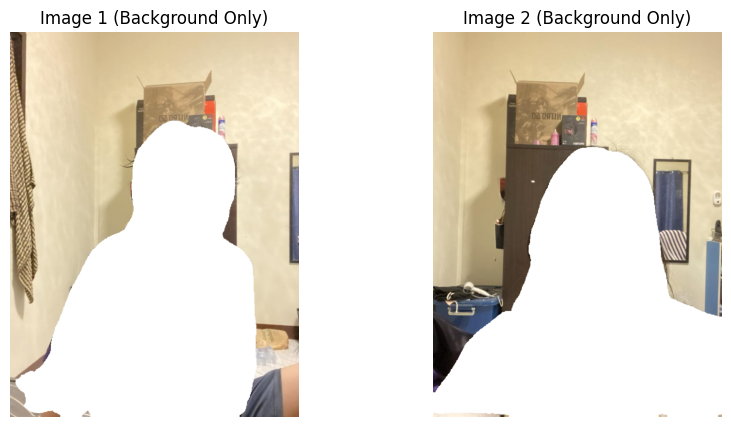

In [30]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import numpy as np

# กำหนด device
device = "cuda" if torch.cuda.is_available() else "cpu"

# โหลดโมเดล CLIP
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# โหลดภาพที่ตัดคนออก
image1 = Image.open("/content/output/image1_with_person_removed.png")
image2 = Image.open("/content/output/image2_with_person_removed.png")

# โหลดภาพ mask ที่ได้จาก DeepLabV3+ (ที่ mask คนออก)
mask_image1 = Image.open("/content/output/segmentation_mask1.png").convert("L")  # Mask เป็นสีขาว (คน) หรือดำ (พื้นหลัง)
mask_image2 = Image.open("/content/output/segmentation_mask2.png").convert("L")

# แปลงภาพ mask เป็น numpy array
mask1 = np.array(mask_image1)
mask2 = np.array(mask_image2)

# สร้างพื้นหลัง (พื้นหลังจะเป็นสีขาวเมื่อไม่ mask)
image1_background = np.array(image1)
image2_background = np.array(image2)

# เปลี่ยนส่วนที่เป็น "คน" ในภาพให้เป็นสีขาว
image1_background[mask1 == 0] = 255  # เมื่อ mask เป็น 0 (คน) ให้เป็นสีขาว
image2_background[mask2 == 0] = 255  # เมื่อ mask เป็น 0 (คน) ให้เป็นสีขาว

# แปลงกลับเป็นภาพ PIL
image1_background = Image.fromarray(image1_background)
image2_background = Image.fromarray(image2_background)

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ CLIP
def clip_similarity(image1, image2):
    inputs = clip_processor(images=[image1, image2], return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
    # ปรับขนาดและ normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features[0] @ image_features[1].T).item()
    return similarity

# เปรียบเทียบภาพ
clip_score = clip_similarity(image1_background, image2_background)

# แสดงผล
print(f"CLIP Similarity Score (Background Only): {clip_score:.4f}")

# แสดงภาพ
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1_background)
plt.title("Image 1 (Background Only)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2_background)
plt.title("Image 2 (Background Only)")
plt.axis("off")

plt.show()


CLIP Similarity Score (Original Image 1 vs Original Image 2): 0.8176


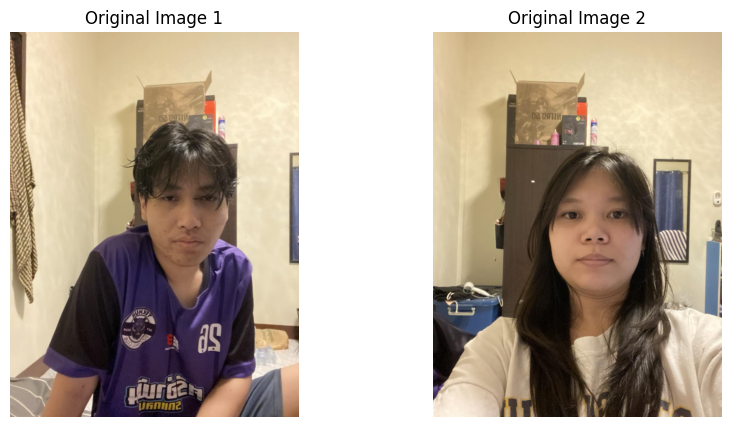

In [29]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import numpy as np

# กำหนด device
device = "cuda" if torch.cuda.is_available() else "cpu"

# โหลดโมเดล CLIP
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# โหลดภาพต้นฉบับ
image1 = Image.open("/content/484306100_1607547476614172_7718928177540118125_n.jpg")
image2 = Image.open("/content/484780875_954835580188785_170552539904722165_n.jpg")

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ CLIP
def clip_similarity(image1, image2):
    inputs = clip_processor(images=[image1, image2], return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
    # ปรับขนาดและ normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features[0] @ image_features[1].T).item()
    return similarity

# เปรียบเทียบภาพต้นฉบับกับภาพต้นฉบับ
clip_score_original = clip_similarity(image1, image2)

# แสดงผล
print(f"CLIP Similarity Score (Original Image 1 vs Original Image 2): {clip_score_original:.4f}")

# แสดงภาพ
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Original Image 2")
plt.axis("off")

plt.show()


CLIP Similarity Score (Background Only): 0.8673


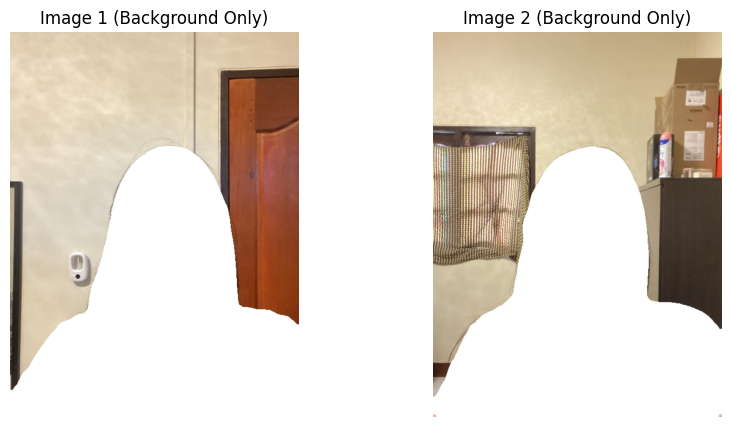

In [32]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import numpy as np

# กำหนด device
device = "cuda" if torch.cuda.is_available() else "cpu"

# โหลดโมเดล CLIP
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# โหลดภาพที่ตัดคนออก
image1 = Image.open("/content/output/image1_with_person_removed.png")
image2 = Image.open("/content/output/image2_with_person_removed.png")

# โหลดภาพ mask ที่ได้จาก DeepLabV3+ (ที่ mask คนออก)
mask_image1 = Image.open("/content/output/segmentation_mask1.png").convert("L")  # Mask เป็นสีขาว (คน) หรือดำ (พื้นหลัง)
mask_image2 = Image.open("/content/output/segmentation_mask2.png").convert("L")

# แปลงภาพ mask เป็น numpy array
mask1 = np.array(mask_image1)
mask2 = np.array(mask_image2)

# สร้างพื้นหลัง (พื้นหลังจะเป็นสีขาวเมื่อไม่ mask)
image1_background = np.array(image1)
image2_background = np.array(image2)

# เปลี่ยนส่วนที่เป็น "คน" ในภาพให้เป็นสีขาว
image1_background[mask1 == 0] = 255  # เมื่อ mask เป็น 0 (คน) ให้เป็นสีขาว
image2_background[mask2 == 0] = 255  # เมื่อ mask เป็น 0 (คน) ให้เป็นสีขาว

# แปลงกลับเป็นภาพ PIL
image1_background = Image.fromarray(image1_background)
image2_background = Image.fromarray(image2_background)

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ CLIP
def clip_similarity(image1, image2):
    inputs = clip_processor(images=[image1, image2], return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
    # ปรับขนาดและ normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features[0] @ image_features[1].T).item()
    return similarity

# เปรียบเทียบภาพ
clip_score = clip_similarity(image1_background, image2_background)

# แสดงผล
print(f"CLIP Similarity Score (Background Only): {clip_score:.4f}")

# แสดงภาพ
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1_background)
plt.title("Image 1 (Background Only)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2_background)
plt.title("Image 2 (Background Only)")
plt.axis("off")

plt.show()


CLIP Similarity Score (Original Image 1 vs Original Image 2): 0.9178


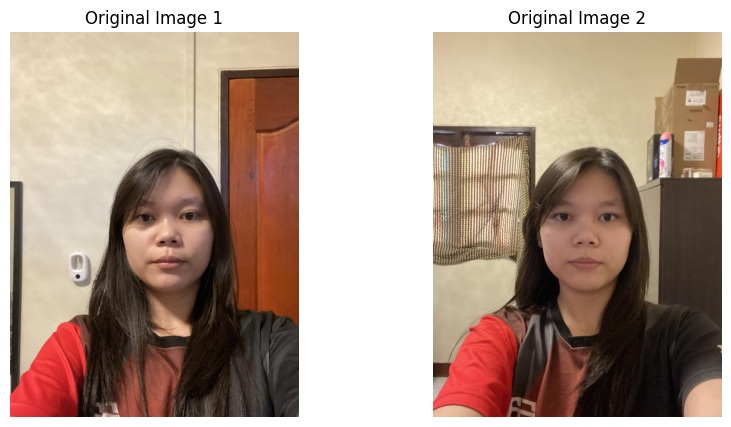

In [36]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import numpy as np

# กำหนด device
device = "cuda" if torch.cuda.is_available() else "cpu"

# โหลดโมเดล CLIP
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# โหลดภาพต้นฉบับ
image1 = Image.open("/content/486162522_617138504815285_7348884604077297056_n.jpg")
image2 = Image.open("/content/487094535_668836015532232_8047246504063472500_n.jpg")

# ฟังก์ชั่นสำหรับการเปรียบเทียบโดยใช้ CLIP
def clip_similarity(image1, image2):
    inputs = clip_processor(images=[image1, image2], return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
    # ปรับขนาดและ normalize
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features[0] @ image_features[1].T).item()
    return similarity

# เปรียบเทียบภาพต้นฉบับกับภาพต้นฉบับ
clip_score_original = clip_similarity(image1, image2)

# แสดงผล
print(f"CLIP Similarity Score (Original Image 1 vs Original Image 2): {clip_score_original:.4f}")

# แสดงภาพ
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Original Image 2")
plt.axis("off")

plt.show()
